In [10]:
# IMPORTACIÓN DE LIBRERÍAS

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# CONFIGURACIÓN

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


# SUBIR EL ARCHIVO

print("Selecciona el archivo dataset_estudiantes.csv")

archivos_subidos = files.upload()


# CARGAR EL DATASET

nombre_archivo = list(archivos_subidos.keys())[0]

df = pd.read_csv(
    io.BytesIO(archivos_subidos[nombre_archivo])
)


# MOSTRAR LOS PRIMEROS REGISTROS

display(df.head())


# DIMENSIONES DEL DATASET

print(
    f"\nEl dataset tiene {df.shape[0]} filas "
    f"y {df.shape[1]} columnas."
)


# INFORMACIÓN GENERAL

print("\nInformación general del dataset:\n")
df.info()


# COMPROBAR DUPLICADOS

print(
    "\nNúmero de filas duplicadas:",
    df.duplicated().sum()
)


# COMPROBAR VALORES NULOS

nulos = pd.DataFrame({
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (
        df.isnull().mean() * 100
    ).round(2)
})

print("\nColumnas con valores nulos:")
display(nulos[nulos["cantidad_nulos"] > 0])


# IDENTIFICAR VARIABLES NUMÉRICAS Y CATEGÓRICAS

columnas_numericas = (
    df.select_dtypes(include=np.number)
    .columns
    .tolist()
)

columnas_categoricas = (
    df.select_dtypes(include="object")
    .columns
    .tolist()
)

print("\nVariables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)


# ESTADÍSTICAS DESCRIPTIVAS

print("\nEstadísticas de las variables numéricas:")
display(
    df[columnas_numericas]
    .describe()
    .T
    .round(2)
)

Selecciona el archivo dataset_estudiantes.csv


Saving dataset_estudiantes.csv to dataset_estudiantes.csv


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad,nivel_dificultad,tiene_tutor,horario_estudio_preferido,estilo_aprendizaje,nota_final,aprobado
0,8.957476,48.830601,86.640182,6.675694,25,Fácil,Sí,Tarde,Lectura/Escritura,84.4,1
1,11.042524,80.825707,83.449655,4.616844,18,Difícil,No,Tarde,NaN,72.0,1
2,4.510776,90.383694,74.623607,7.755246,25,Fácil,No,Mañana,Lectura/Escritura,80.0,1
3,6.647213,81.878257,82.849841,8.592826,23,Fácil,No,NaN,Visual,78.2,1
4,1.000000,66.254179,54.539935,6.671840,21,Medio,No,NaN,Auditivo,66.0,1



El dataset tiene 1000 filas y 11 columnas.

Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   horas_estudio_semanal      1000 non-null   float64
 1   nota_anterior              1000 non-null   float64
 2   tasa_asistencia            1000 non-null   float64
 3   horas_sueno                850 non-null    float64
 4   edad                       1000 non-null   int64  
 5   nivel_dificultad           1000 non-null   object 
 6   tiene_tutor                1000 non-null   object 
 7   horario_estudio_preferido  900 non-null    object 
 8   estilo_aprendizaje         950 non-null    object 
 9   nota_final                 1000 non-null   float64
 10  aprobado                   1000 non-null   int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 86.1+ KB

Número de filas duplica

,cantidad_nulos,porcentaje_nulos
horas_sueno,150,15.0
horario_estudio_preferido,100,10.0
estilo_aprendizaje,50,5.0



Variables numéricas:
['horas_estudio_semanal', 'nota_anterior', 'tasa_asistencia', 'horas_sueno', 'edad', 'nota_final', 'aprobado']

Variables categóricas:
['nivel_dificultad', 'tiene_tutor', 'horario_estudio_preferido', 'estilo_aprendizaje']

Estadísticas de las variables numéricas:


,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,10.07,4.85,1.0,6.63,10.00,13.37,25.0
nota_anterior,1000.0,69.89,14.69,30.0,59.88,70.00,80.12,100.0
tasa_asistencia,1000.0,73.99,18.20,20.0,61.51,75.00,88.49,100.0
horas_sueno,850.0,7.01,1.44,4.0,6.00,7.02,8.02,10.0
edad,1000.0,23.53,3.48,18.0,21.00,24.00,27.00,29.0
nota_final,1000.0,71.44,9.56,30.0,64.78,71.40,77.90,100.0
aprobado,1000.0,0.90,0.30,0.0,1.00,1.00,1.00,1.0


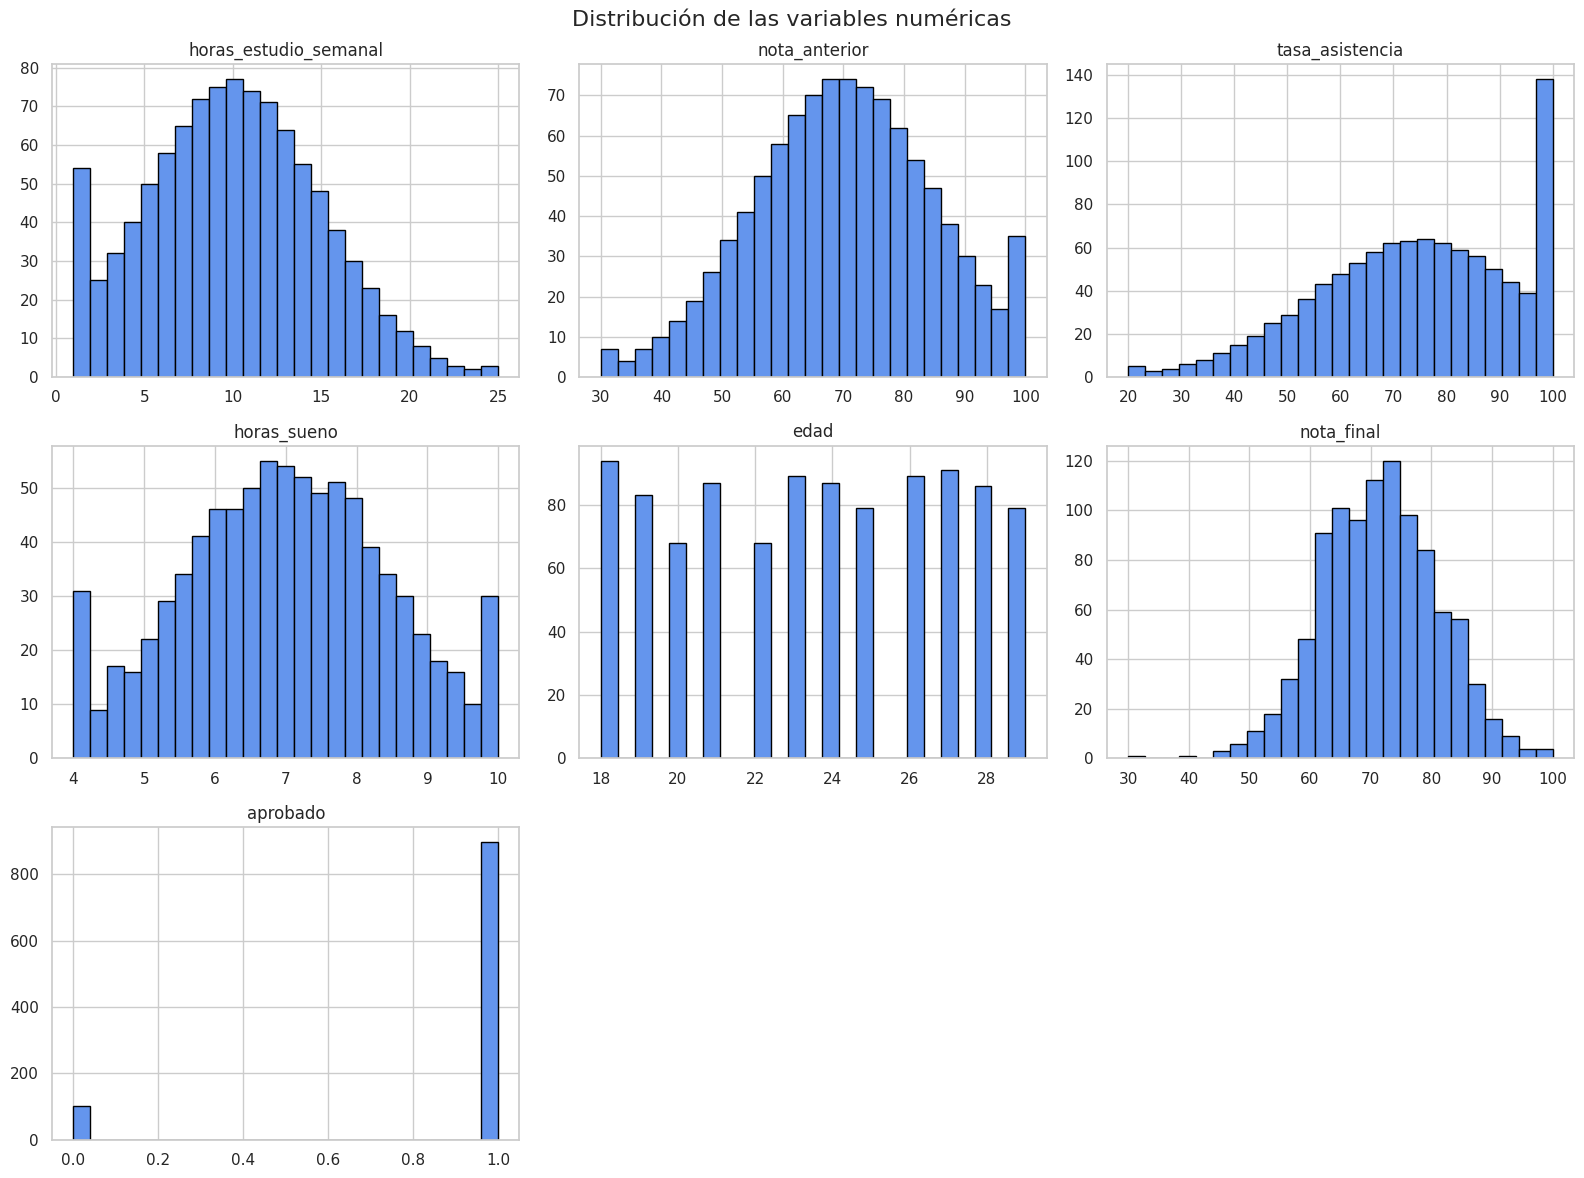

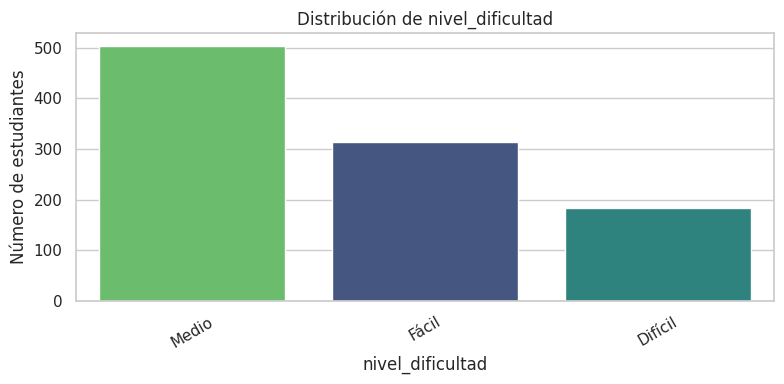

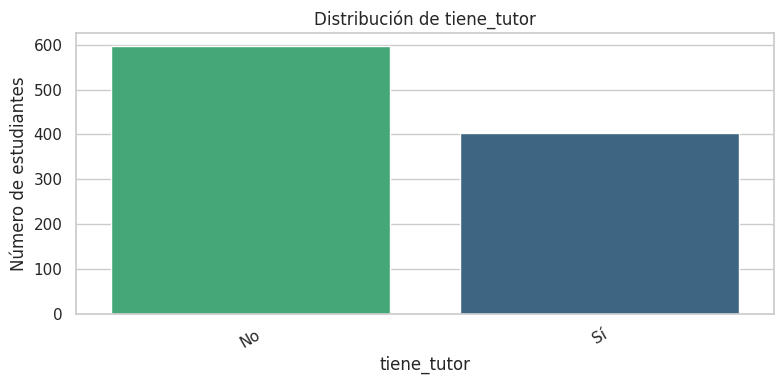

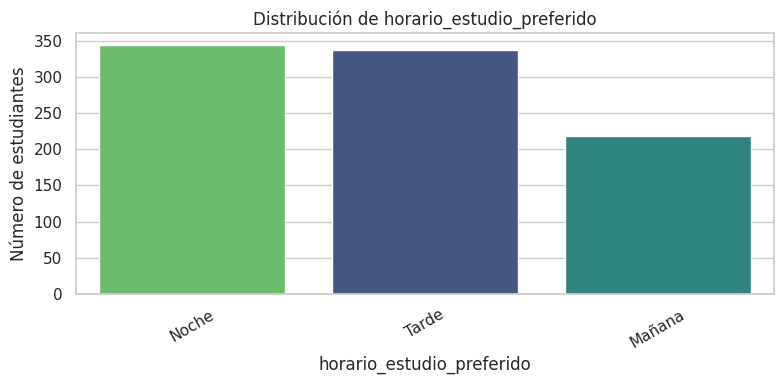

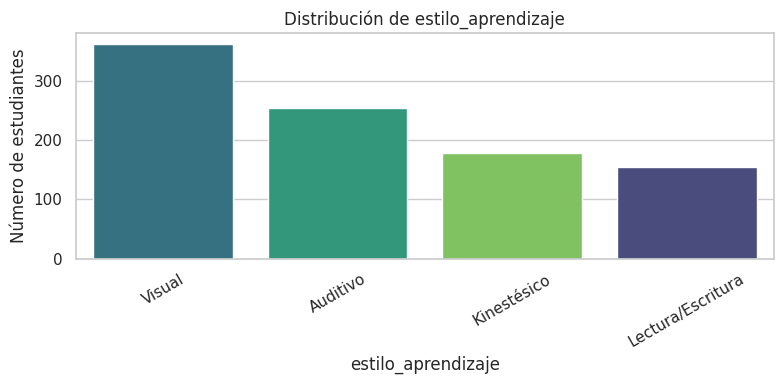

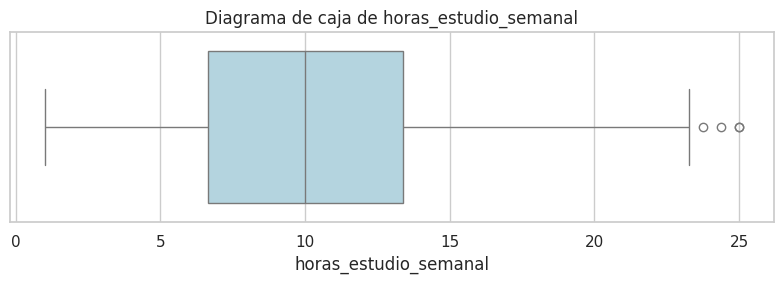

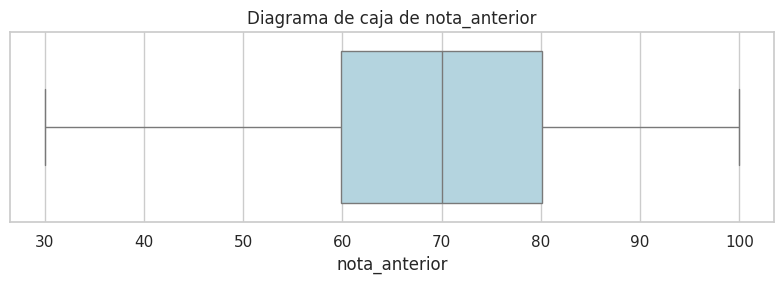

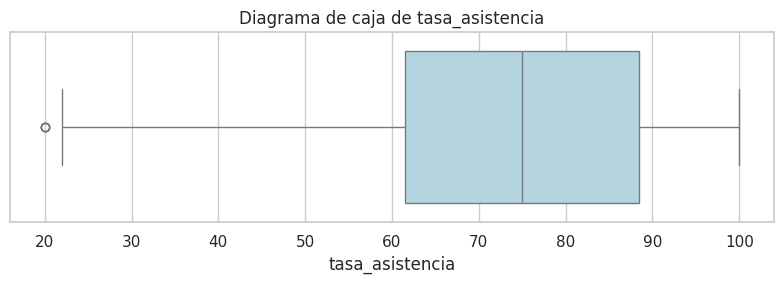

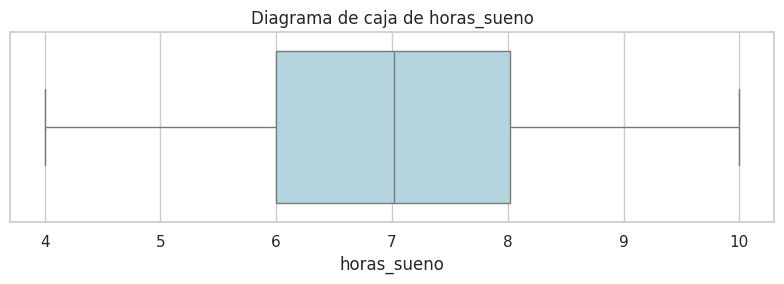

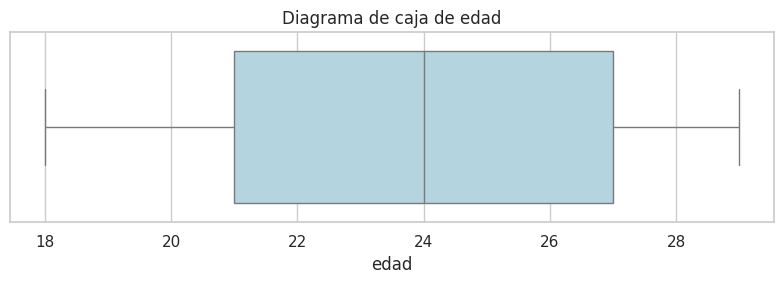

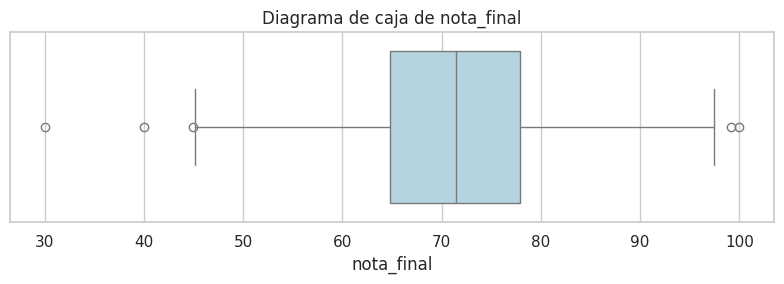

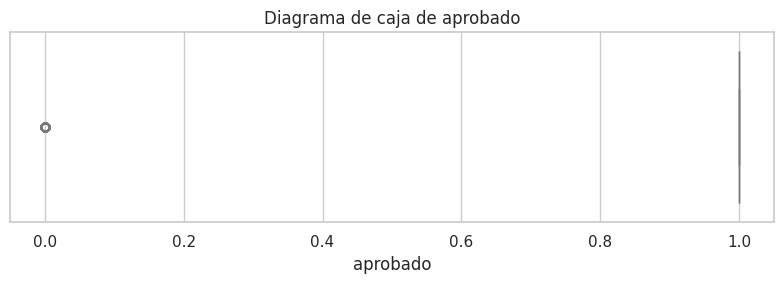

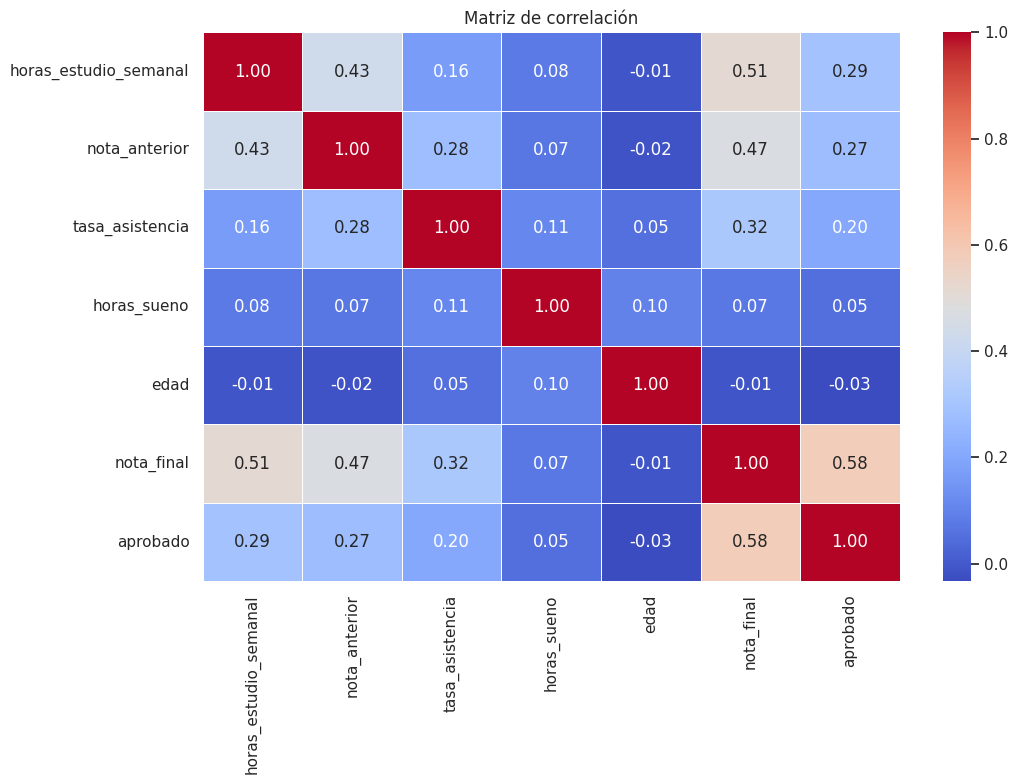

Correlaciones con la nota final:


,nota_final
nota_final,1.000000
aprobado,0.578919
horas_estudio_semanal,0.513565
nota_anterior,0.469787
tasa_asistencia,0.316773
horas_sueno,0.074635
edad,-0.012204


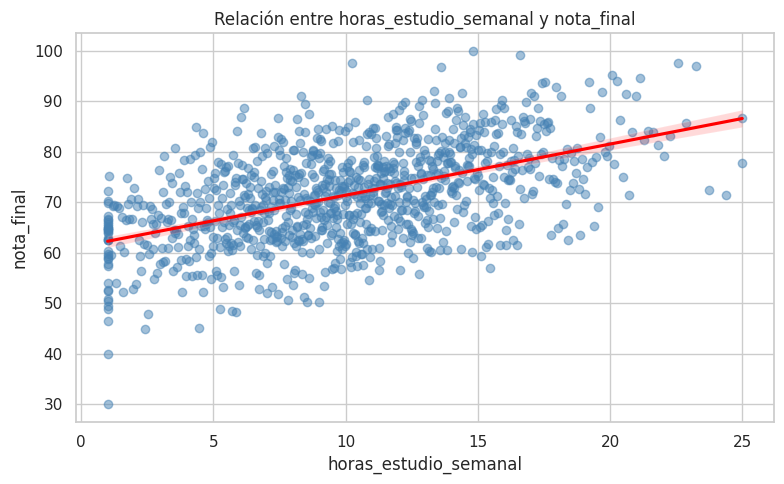

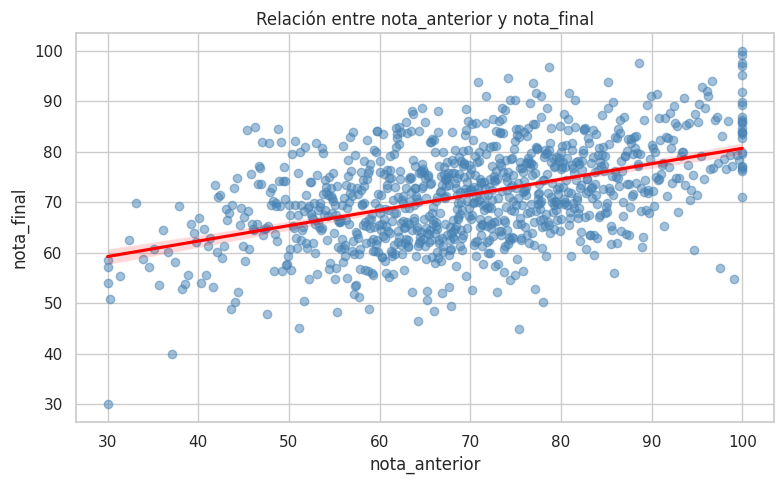

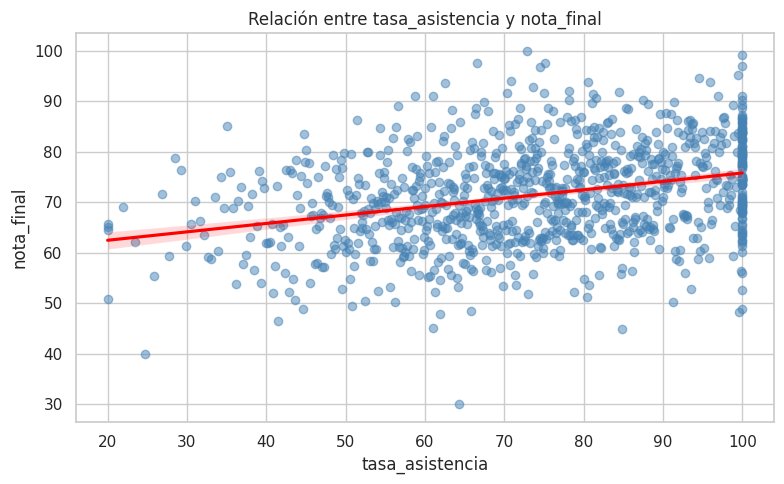

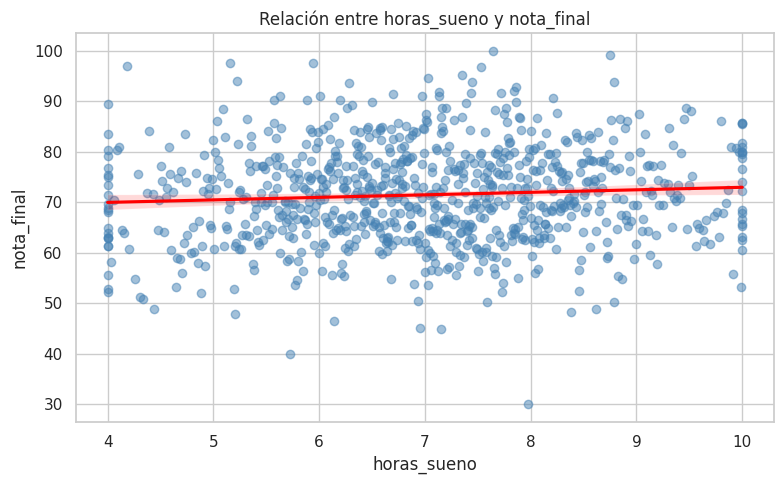

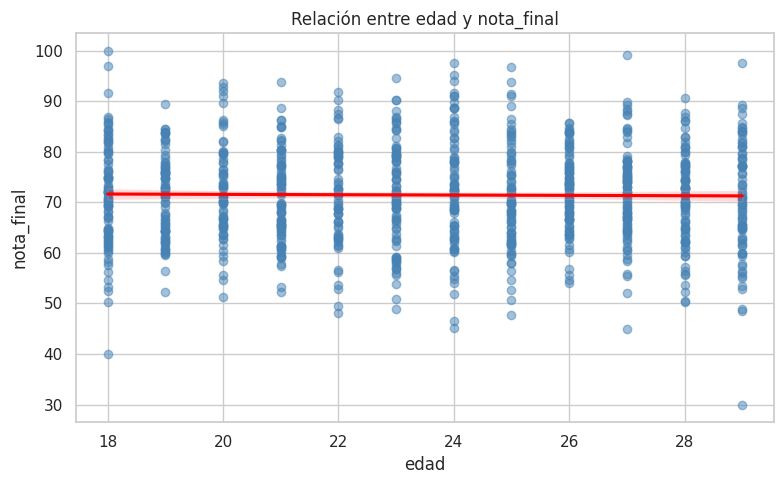

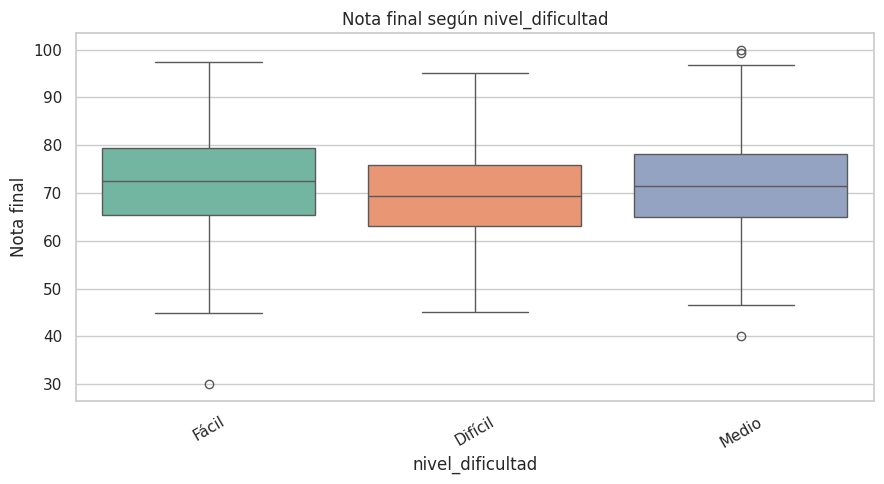

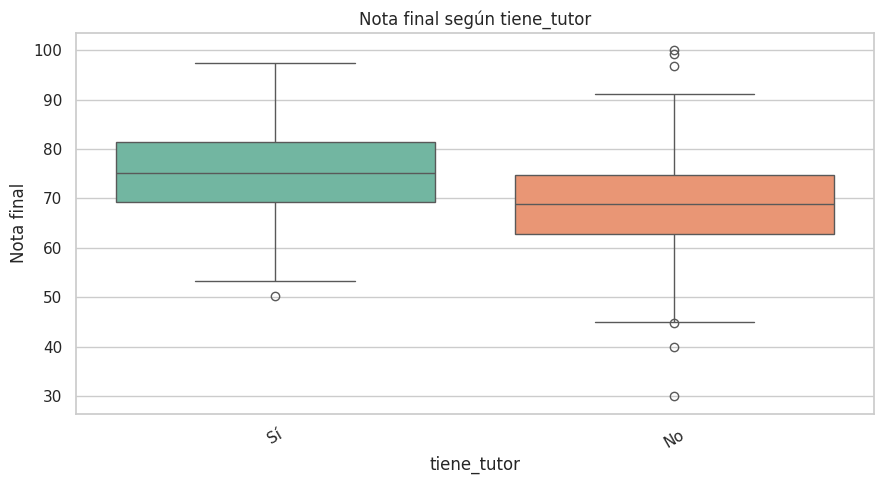

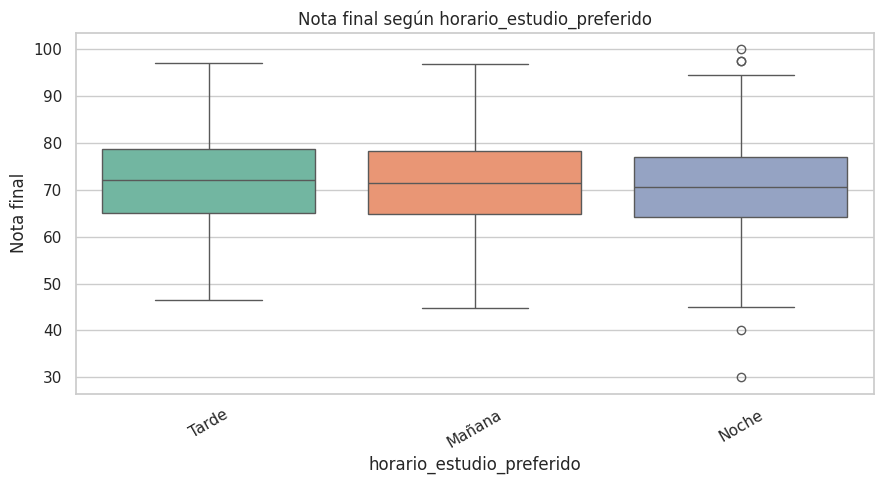

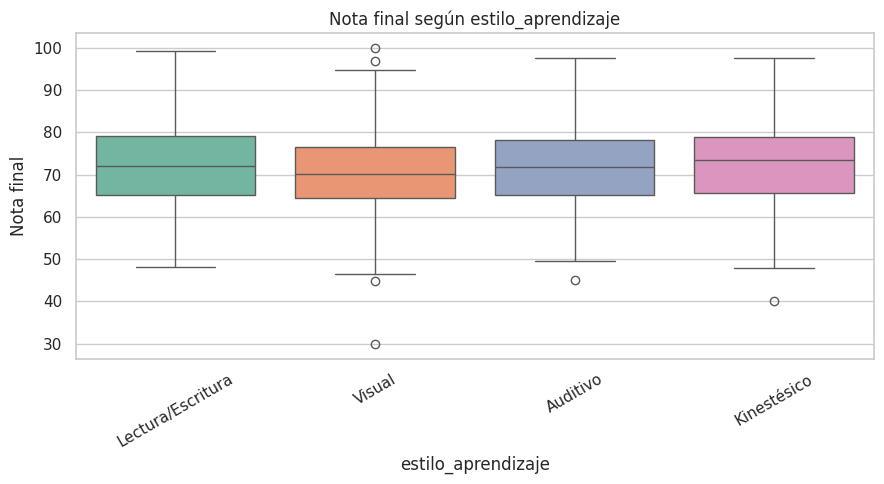

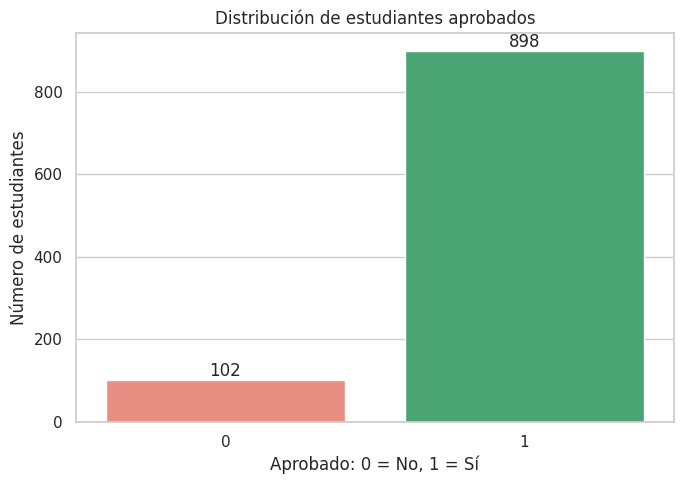

Distribución de la variable aprobado:


,cantidad,porcentaje
aprobado,,
0,102,10.2
1,898,89.8


Valores medios según resultado académico:


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad
aprobado,,,,,
0,5.86,58.10,62.97,6.79,23.87
1,10.55,71.22,75.24,7.03,23.49


Nota final según disponibilidad de tutor:


,count,mean,median
tiene_tutor,,,
No,597,68.84,68.8
Sí,403,75.29,75.2


Nota final según nivel de dificultad:


,count,mean,median
nivel_dificultad,,,
Difícil,183,69.48,69.40
Fácil,313,72.50,72.60
Medio,504,71.49,71.45


In [11]:
# ============================================================
# ANÁLISIS EXPLORATORIO Y VISUALIZACIONES
# ============================================================


# 1. DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS

df[columnas_numericas].hist(
    figsize=(16, 12),
    bins=25,
    edgecolor="black",
    color="cornflowerblue"
)

plt.suptitle(
    "Distribución de las variables numéricas",
    fontsize=16
)

plt.tight_layout()
plt.show()


# 2. DISTRIBUCIÓN DE LAS VARIABLES CATEGÓRICAS

for columna in columnas_categoricas:

    plt.figure(figsize=(8, 4))

    orden = df[columna].value_counts().index

    sns.countplot(
        data=df,
        x=columna,
        order=orden,
        hue=columna,
        legend=False,
        palette="viridis"
    )

    plt.title(f"Distribución de {columna}")
    plt.xlabel(columna)
    plt.ylabel("Número de estudiantes")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# 3. DIAGRAMAS DE CAJA PARA BUSCAR VALORES ATÍPICOS

for columna in columnas_numericas:

    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=columna,
        color="lightblue"
    )

    plt.title(f"Diagrama de caja de {columna}")
    plt.xlabel(columna)
    plt.tight_layout()
    plt.show()


# 4. MATRIZ DE CORRELACIÓN

correlaciones = df[columnas_numericas].corr()

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlaciones,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


# 5. CORRELACIONES CON LA NOTA FINAL

correlacion_nota = (
    correlaciones["nota_final"]
    .sort_values(ascending=False)
)

print("Correlaciones con la nota final:")
display(correlacion_nota)


# 6. RELACIÓN ENTRE VARIABLES NUMÉRICAS Y NOTA FINAL

variables_regresion = [
    "horas_estudio_semanal",
    "nota_anterior",
    "tasa_asistencia",
    "horas_sueno",
    "edad"
]

for columna in variables_regresion:

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=df,
        x=columna,
        y="nota_final",
        scatter_kws={
            "alpha": 0.5,
            "color": "steelblue"
        },
        line_kws={
            "color": "red"
        }
    )

    plt.title(
        f"Relación entre {columna} y nota_final"
    )

    plt.tight_layout()
    plt.show()


# 7. RELACIÓN ENTRE VARIABLES CATEGÓRICAS Y NOTA FINAL

for columna in columnas_categoricas:

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df,
        x=columna,
        y="nota_final",
        hue=columna,
        legend=False,
        palette="Set2"
    )

    plt.title(
        f"Nota final según {columna}"
    )

    plt.xlabel(columna)
    plt.ylabel("Nota final")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# 8. DISTRIBUCIÓN DE LA VARIABLE APROBADO

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="aprobado",
    hue="aprobado",
    legend=False,
    palette=["salmon", "mediumseagreen"]
)

plt.title("Distribución de estudiantes aprobados")
plt.xlabel("Aprobado: 0 = No, 1 = Sí")
plt.ylabel("Número de estudiantes")

for barra in ax.patches:

    altura = barra.get_height()

    ax.annotate(
        f"{int(altura)}",
        (
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# 9. PORCENTAJES DE APROBADOS Y SUSPENDIDOS

distribucion_aprobado = (
    df["aprobado"]
    .value_counts()
    .sort_index()
)

porcentaje_aprobado = (
    df["aprobado"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

resumen_aprobado = pd.DataFrame({
    "cantidad": distribucion_aprobado,
    "porcentaje": porcentaje_aprobado
})

print("Distribución de la variable aprobado:")
display(resumen_aprobado)


# 10. COMPARACIÓN DE VARIABLES SEGÚN APROBADO

variables_comparacion = [
    "horas_estudio_semanal",
    "nota_anterior",
    "tasa_asistencia",
    "horas_sueno",
    "edad"
]

resumen_por_resultado = (
    df.groupby("aprobado")[variables_comparacion]
    .mean()
    .round(2)
)

print("Valores medios según resultado académico:")
display(resumen_por_resultado)


# 11. NOTA FINAL MEDIA SEGÚN TUTOR

nota_tutor = (
    df.groupby("tiene_tutor", dropna=False)
    ["nota_final"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("Nota final según disponibilidad de tutor:")
display(nota_tutor)


# 12. NOTA FINAL SEGÚN NIVEL DE DIFICULTAD

nota_dificultad = (
    df.groupby("nivel_dificultad", dropna=False)
    ["nota_final"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("Nota final según nivel de dificultad:")
display(nota_dificultad)

In [ ]:
## Conclusiones del análisis exploratorio

El conjunto de datos contiene 1.000 estudiantes y 11 variables. No se han detectado filas duplicadas.

Se han identificado valores ausentes en tres variables: `horas_sueno`, `horario_estudio_preferido` y `estilo_aprendizaje`. Estos valores se tratarán durante la fase de preprocesamiento.

La variable `nota_final` presenta una distribución centrada aproximadamente en los 71 puntos. Las variables con una relación positiva más clara con la nota final son las horas de estudio semanales, la nota anterior y la tasa de asistencia.

La disponibilidad de tutor también parece estar asociada con mejores resultados académicos. En cambio, la edad y las horas de sueño muestran una relación lineal más débil con la nota final.

La variable objetivo `aprobado` está desbalanceada, ya que aproximadamente el 90 % de los estudiantes pertenece a la clase de aprobados. Por este motivo, durante la evaluación del modelo de clasificación no será suficiente utilizar únicamente la exactitud o accuracy. También deberán estudiarse precision, recall, F1-score, matriz de confusión y ROC-AUC.

En la fase de modelado se evitará la fuga de información. Para regresión se eliminará la variable `aprobado`, porque deriva de la nota final. Para clasificación se eliminará `nota_final`, ya que determina directamente si el estudiante ha aprobado.